In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/german_credit_data.csv") 
df_raw = df.copy()

In [19]:
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [20]:
df.shape

(1000, 21)

In [26]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [22]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [23]:
df.describe(include='object')

,status_account,credit_history,purpose,status_savings,years_employment,status_and_sex,secondary_obligor,collateral,other_installment_plans,housing,job,telephone,is_foreign_worker,target
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2,2
top,no checking account,existing credits paid back duly till now,radio/television,< 100 DM,1 to < 4 years,male : single,none,real estate,none,own,skilled employee/ official,none,yes,good
freq,394,530,280,603,339,548,907,332,814,713,630,596,963,700


In [24]:
df.isnull().sum().sort_values(ascending=False)

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

In [25]:
df.nunique().sort_values(ascending=False)

credit_amount              921
age                         53
month_duration              33
purpose                     10
credit_history               5
years_employment             5
status_savings               5
status_account               4
payment_to_income_ratio      4
status_and_sex               4
residence_since              4
collateral                   4
job                          4
n_credits                    4
secondary_obligor            3
housing                      3
other_installment_plans      3
n_guarantors                 2
telephone                    2
is_foreign_worker            2
target                       2
dtype: int64

In [27]:
df['target'].value_counts()

target
good    700
bad     300
Name: count, dtype: int64

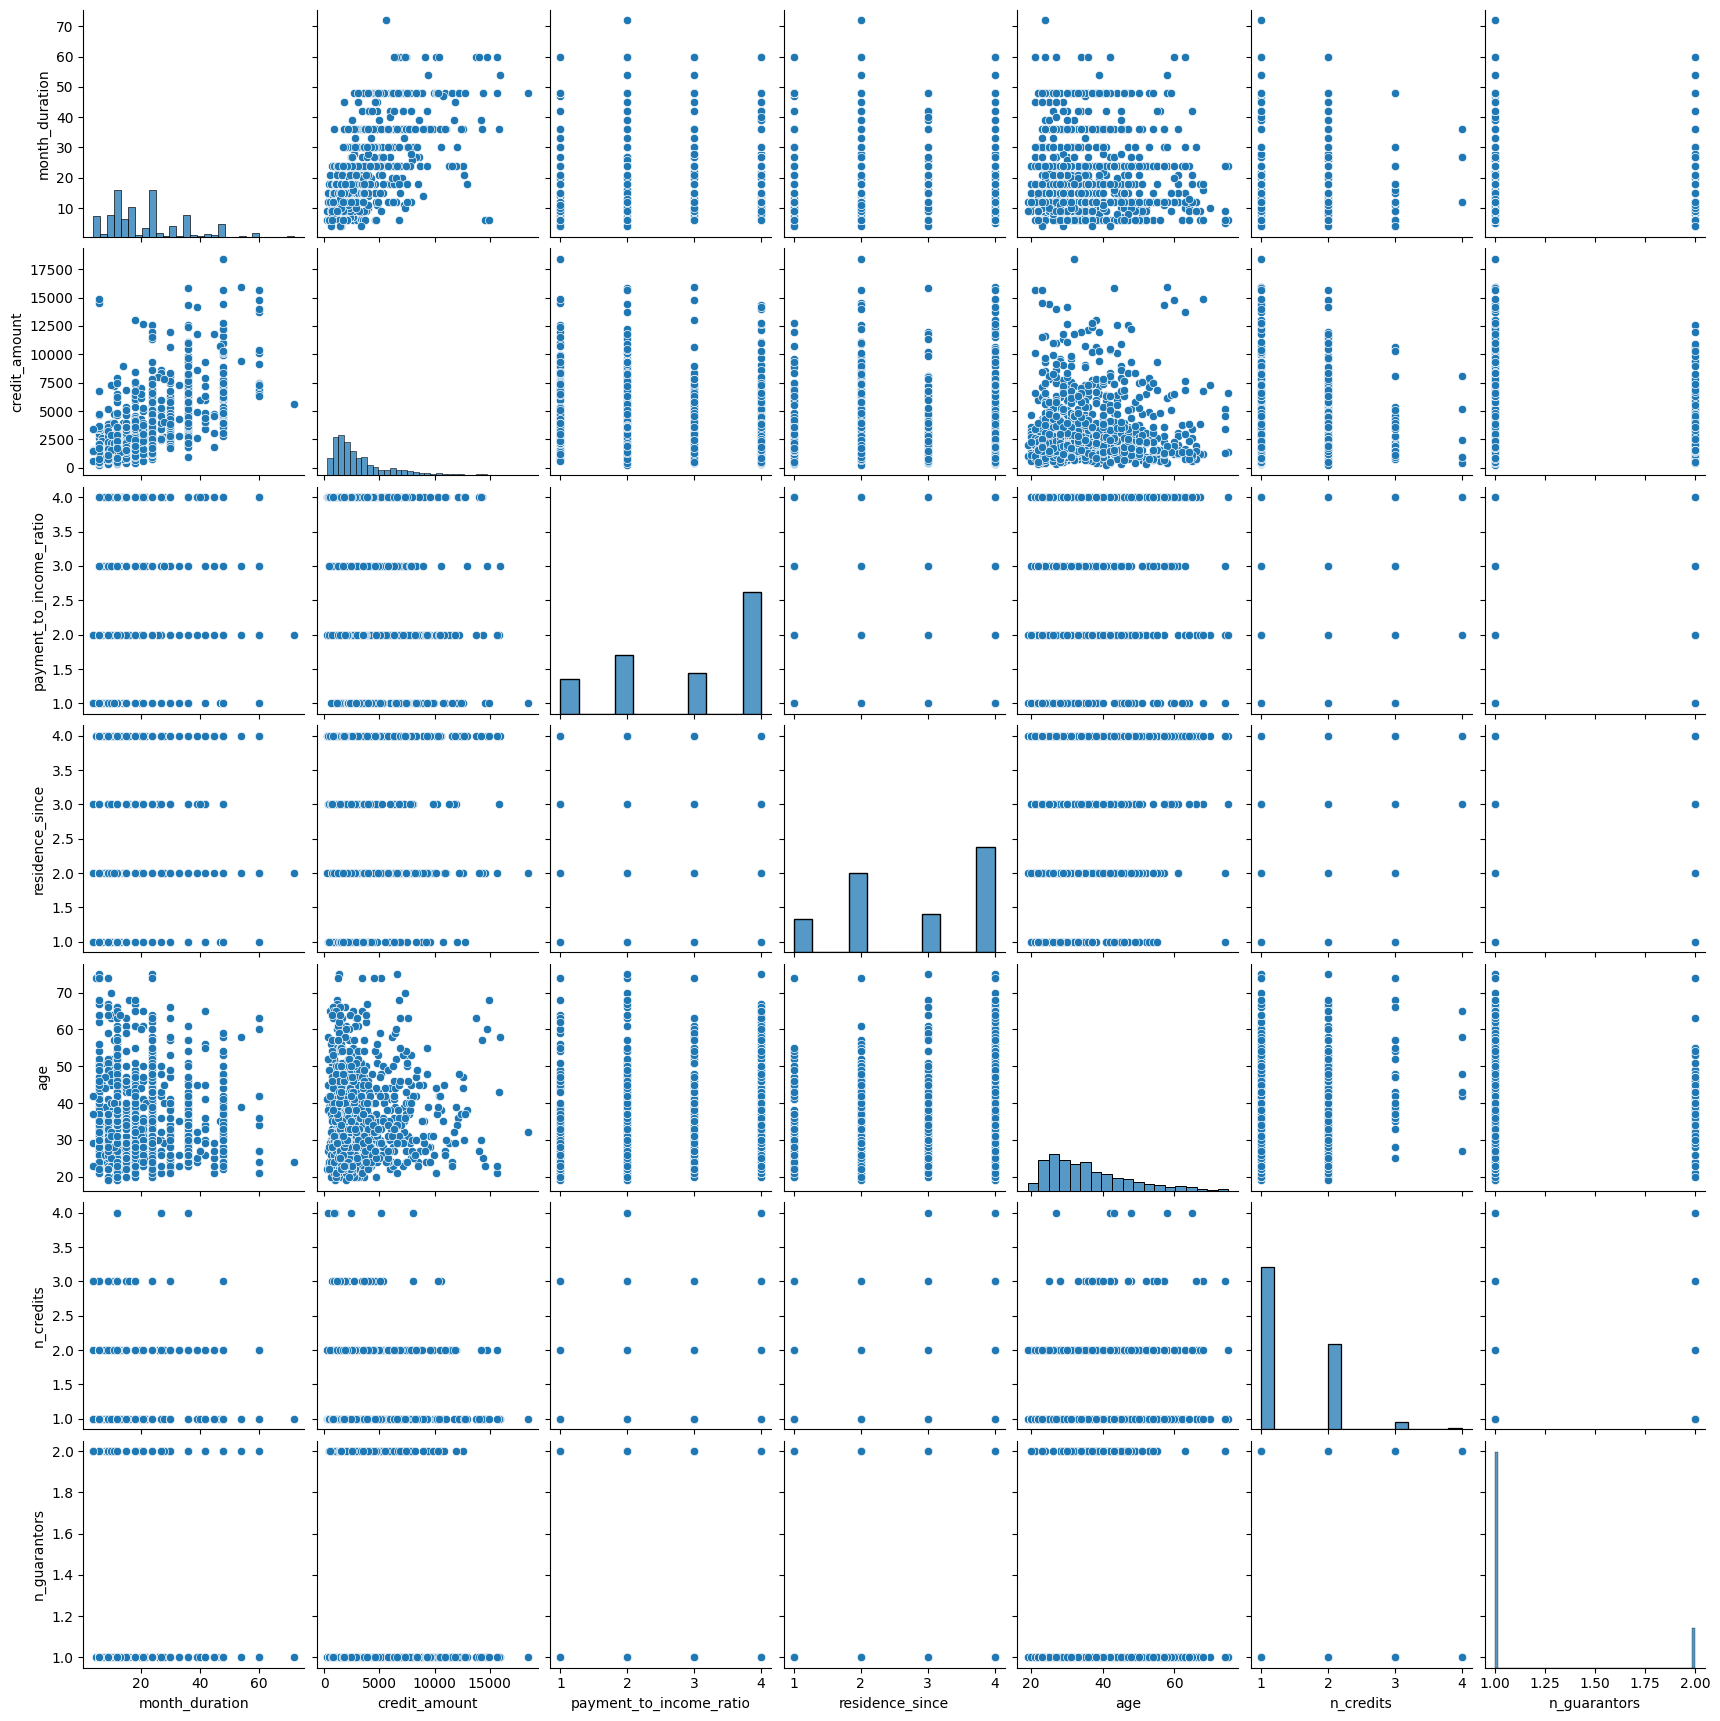

In [30]:
numerical_cols = df.select_dtypes(include='number').columns
sns.pairplot(df[numerical_cols])

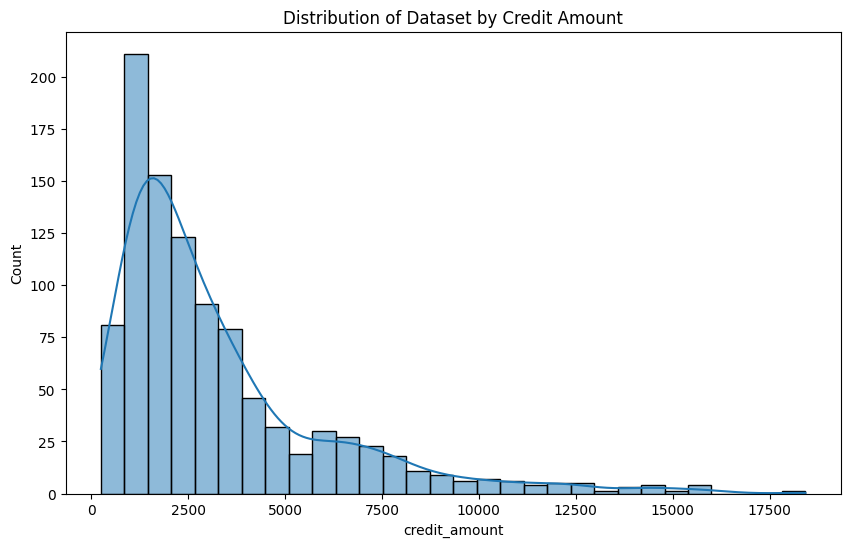

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['credit_amount'],bins=30, kde=True)
plt.title('Distribution of Dataset by Credit Amount')
plt.show()

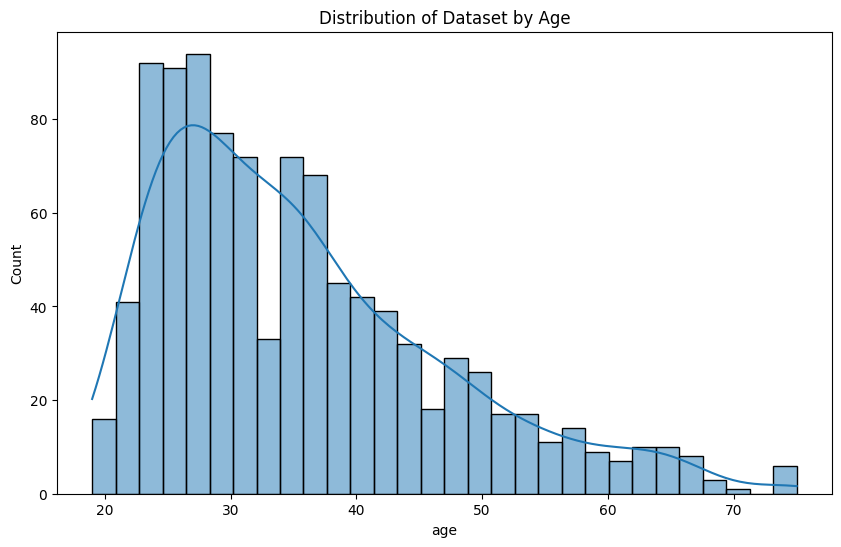

In [29]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['age'],bins=30, kde=True)
plt.title('Distribution of Dataset by Age')
plt.show()


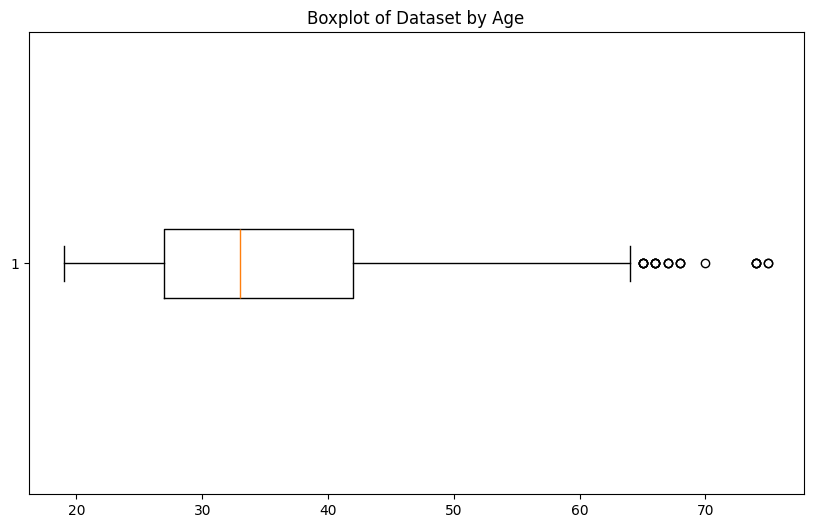

In [43]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
plt.boxplot(df['age'], vert=False)
plt.title('Boxplot of Dataset by Age')
plt.show()


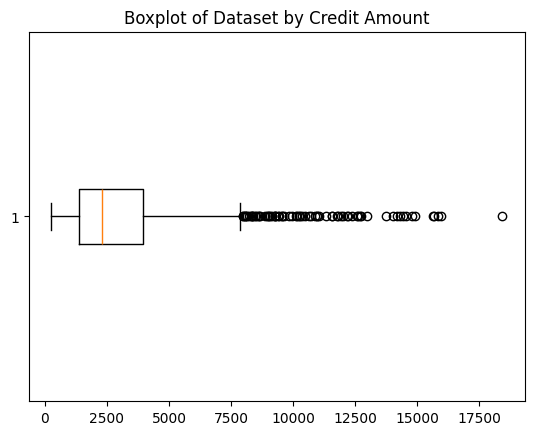

In [41]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.boxplot(df['credit_amount'], vert=False)
plt.title('Boxplot of Dataset by Credit Amount')
plt.show()
